   Year  Predicted_Product_Movement
0  2041                  246.510573
1  2042                  250.940171
2  2043                  255.369768
3  2044                  259.799366
4  2045                  264.228963
5  2046                  268.658561
6  2047                  273.088159
7  2048                  277.517756
8  2049                  281.947354
9  2050                  286.376951


C:\Users\Pranesh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


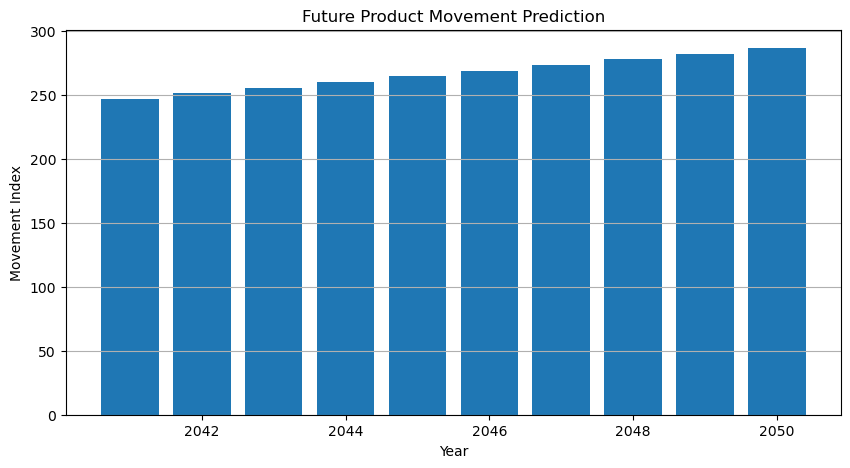

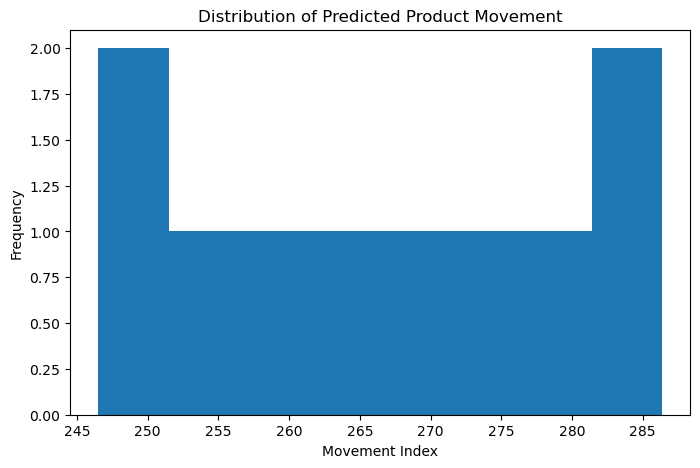

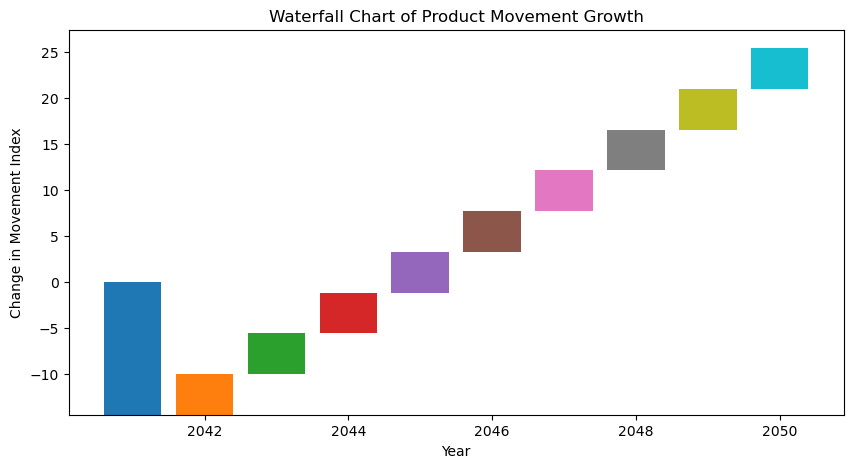

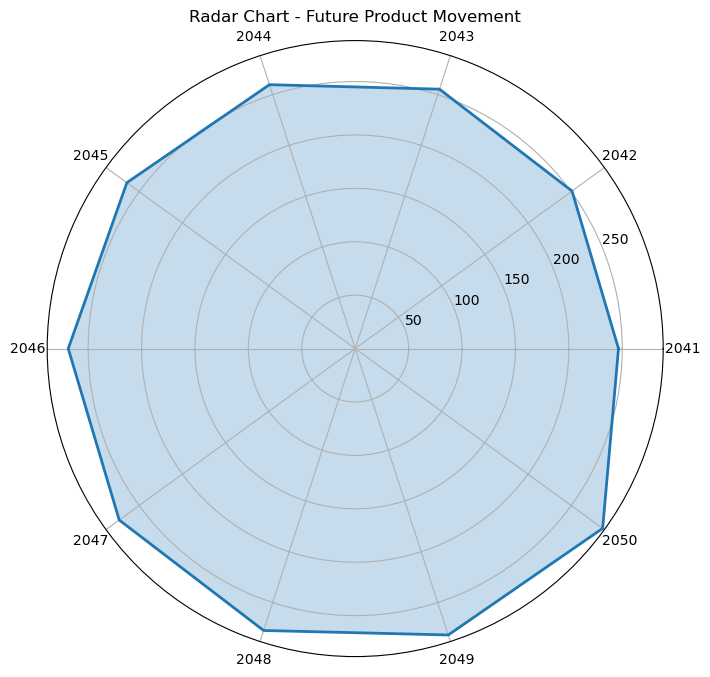


Prediction file saved successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load Dataset
df = pd.read_csv("hardware_industry_electrical_consumption_2000_2040.csv")

# Feature and Target
X = df[['Year']]
y = df['Product_Movement_Index']

# Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Future Years Prediction (2041-2050)
future_years = np.arange(2041, 2051).reshape(-1, 1)
future_predictions = model.predict(future_years)

future_df = pd.DataFrame({
    'Year': future_years.flatten(),
    'Predicted_Product_Movement': future_predictions
})

print(future_df)

# ====================================================
# 1. BAR GRAPH
# ====================================================
plt.figure(figsize=(10,5))
plt.bar(
    future_df['Year'],
    future_df['Predicted_Product_Movement']
)
plt.title("Future Product Movement Prediction")
plt.xlabel("Year")
plt.ylabel("Movement Index")
plt.grid(axis='y')
plt.show()

# ====================================================
# 2. HISTOGRAM
# ====================================================
plt.figure(figsize=(8,5))
plt.hist(
    future_df['Predicted_Product_Movement'],
    bins=8
)
plt.title("Distribution of Predicted Product Movement")
plt.xlabel("Movement Index")
plt.ylabel("Frequency")
plt.show()

# ====================================================
# 3. WATERFALL CHART
# ====================================================
changes = np.diff(
    np.insert(
        future_predictions,
        0,
        y.iloc[-1]
    )
)

cumulative = np.cumsum(changes)

plt.figure(figsize=(10,5))

for i in range(len(changes)):
    plt.bar(
        future_df['Year'][i],
        changes[i],
        bottom=cumulative[i]-changes[i]
    )

plt.title("Waterfall Chart of Product Movement Growth")
plt.xlabel("Year")
plt.ylabel("Change in Movement Index")
plt.show()

# ====================================================
# 4. RADAR CHART
# ====================================================
categories = future_df['Year'].astype(str).tolist()
values = future_df['Predicted_Product_Movement'].tolist()

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Radar Chart - Future Product Movement")
plt.show()

# ====================================================
# SAVE PREDICTIONS
# ====================================================
future_df.to_csv(
    "future_product_movement_predictions.csv",
    index=False
)

print("\nPrediction file saved successfully.")